<a href="https://colab.research.google.com/github/predpoke/SuperSecondProject/blob/main/SuperPorjectCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
import torch
import torch.nn as nn


In [ ]:
import os

for root, dirs, files, in os.walk(path) :
  print("현재 폴더  :",  root)
  print("폴더들 :", dirs[:5])
  print("파일들 :", files[:5])
  print("_" * 50)

현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000
폴더들 : ['HAM10000_images_part_1', 'ham10000_images_part_1', 'HAM10000_images_part_2', 'ham10000_images_part_2']
파일들 : ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']
__________________________________________________
현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1
폴더들 : []
파일들 : ['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
__________________________________________________
현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1
폴더들 : []
파일들 : ['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
__________________________________________________
현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2
폴더들 : []
파일들 : ['ISIC_0030912.jpg', 'ISIC_0030585.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg']

(600, 450)


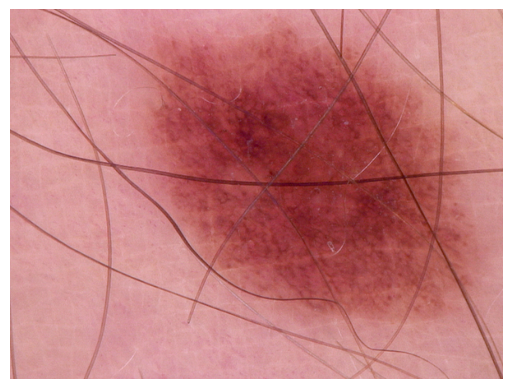

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_dir1 = os.path.join(path, "HAM10000_images_part_1")
img_dir2 = os.path.join(path, "HAM10000_images_part_2")

sample_img = os.listdir(img_dir1)[0]
img_path = os.path.join(img_dir1, sample_img)
#그러니까 이게 처음에 파일 이름 하나만 꺼내오고
# 그 다음에 경로까지 받아와야 열린대

img = Image.open(img_path)
print(img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

#즉 이 클래스는 데이터를 가공할 자료들인거지



In [ ]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split

csv_path = os.path.join(path, "HAM10000_metadata.csv")
df = pd.read_csv(csv_path)

print(df.head())

#이걸 자꾸 헷갈려 하는데 ,클래스 내부에 생성자잖아 그러니까 초기화 구문이어서 이걸 자꾸 어렵게 받아들이면 안됨
#그래서 내가 각각 사용할 데이터들을 전부 좀 처음부터 정리해서 쓰자 이런 느낌임



all_classes = sorted(df["dx"].unique())
label2idx = {label : idx for idx, label in enumerate(all_classes)}
    #문자열을 숫자로 바꿈
idx2label = {idx : label for label, idx in label2idx.items()}
#얘는 사람이 보려고 만든거 그러니까 숫자에서 다시 라벨로 만들어줌
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


train_df, temp_df = train_test_split(
    df,
    test_size = 0.2,
    random_state= 42,
    shuffle=True
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state= 42,
    shuffle=True
)



class HAM10000Dataset(Dataset) :
  def __init__(self, df, img_dir1, img_dir2=None, transform = None, label2idx = None):
    self.df = df.reset_index(drop=True)
    self.label2idx = label2idx

    self.img_dir1 = img_dir1
    self.img_dir2 = img_dir2

    self.transform =transform



  def __len__(self) :
    return len(self.df)
#몇개 있는지

  def __getitem__(self, idx) :
    row = self.df.iloc[idx]
#n번재 데이터 달라고 할때
    image_id = row["image_id"]
    dx = row["dx"]
    label = self.label2idx[dx]


    file_name = image_id + ".jpg"

    img_path1 = os.path.join(self.img_dir1, file_name)

    if os.path.exists(img_path1) :
      img_path = img_path1
    else :
      img_path2 = os.path.join(self.img_dir2, file_name)
      img_path = img_path2

    image = Image.open(img_path).convert("RGB")

    if self.transform is not None :
      image = self.transform(image)


    return image, label


print("train :", len(train_df))
print("val :", len(val_df))
print("test :", len(test_df))
print("total:", len(df))

#small_train_df = train_df.sample(frac=0.1, random_state=42)
#small_train_dataset = HAM10000Dataset(
 #   small_train_df,
 ##   img_dir1,
   # img_dir2,
   # transform=transform,
   # label2idx=label2idx

#)


train_dataset = HAM10000Dataset(train_df, img_dir1, img_dir2, transform=transform, label2idx =label2idx)
val_dataset = HAM10000Dataset(val_df, img_dir1, img_dir2, transform=transform, label2idx=label2idx)
test_dataset = HAM10000Dataset(test_df, img_dir1, img_dir2, transform=transform, label2idx=label2idx)

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size= 64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size= 64, shuffle=True)

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
train : 8012
val : 1001
test : 1002
total: 10015


In [ ]:
#전체 클래스의 흐름

# Csv에서 0번째 행을 꺼냄
# 그 행에서 image_id 와 dx를 가져옴
# image_id로 실제 이미지 파일 경로를 찾음
# 이미지를 열고 전처리
# dx를 숫자 라벨로 바꿈
# (image, label)을 반환

#내부에서 일어나느 일을 기억하자 dataset에서
# CSV n번째 행 읽기 -> image_id 꺼내기 -> dx 꺼내기 -> dx를 숫자라벨로 반환 -> image_id로 jpg 파일 찾기 -> 이미지 열기 -< transform 적용 -< (image,label) 반환



#train : 모델이 실제로 공부하는 데이터
# val(validation) : 공부 중간에 성적 확인하는 데이터
# test 공부가 끝난 뒤 최종 실전 시험 보는 데이터



In [ ]:
class CIFAR_CNN(nn.Module) :
  def __init__(self) :
    super().__init__()

    self.conv_block = nn.Sequential(
        nn.Conv2d(3,32,kernel_size=3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size = 3, padding =1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )


    self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 28 * 28, 256),
        nn.ReLU(),
        nn.Linear(256, 7)
    )

  def forward(self, x) :
    x = self.conv_block(x)
    x = self.fc(x)
    return x


In [ ]:
# class SkinCancerCNN(nn.Module) :
#   def __init__(self, num_classes=7) :
#     super().__init__()
#     self.features = nn.Sequential(
#         nn.Conv2d(3, 32, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),

#         nn.Conv2d(32, 64, kernel_size=3 , padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),

#         nn.Conv2d(64, 128, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),
#     )

#     self.classifier = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(128 * 28 * 28, 256),
#         nn.ReLU(),
#         nn.Dropout(0.3),
#         nn.Linear(256, num_classes)
#     )

#   def forward(self, x) :
#     x = self.features(x)
#     x = self.classifier(x)
#     return x

#구조라는게 음 여기는 순전파 부분을 이제 저렇게 배치해서 따로 빼놓았는데
# Sequential로 이걸 묶여놔서 이걸 똑같이 묶으면 되지 않나 싶은데 지금

In [ ]:
class ResNetCNN(nn.Module) :
  class ResidualBlock(nn.Module) :
    def __init__(self, channels) :
      super().__init__()
      self.conv1= nn.Conv2d(channels, channels, kernel_size=3, padding=1)
      self.relu = nn.ReLU()
      self.conv2= nn.Conv2d(channels, channels, kernel_size=3, padding=1)


    def forward(self, x) :
      identity = x
      out = self.conv1(x)
      out = self.relu(out)
      out = self.conv2(out)
      out = out +identity
      out = self.relu(out)
      return out



  def __init__(self, num_classes=7) :
    super().__init__()


    self.features = nn.Sequential(
         nn.Conv2d(3, 32, kernel_size=3, padding=1),
         nn.ReLU(),
         self.ResidualBlock(32),
         nn.MaxPool2d(2),

         nn.Conv2d(32, 64, kernel_size=3, padding=1),
         nn.ReLU(),
         self.ResidualBlock(64),
         nn.MaxPool2d(2),

         nn.Conv2d(64, 128, kernel_size=3, padding=1),
         nn.ReLU(),
         self.ResidualBlock(128),
         nn.MaxPool2d(2),
    )



    self.Classifier = nn.Sequential(
         nn.Flatten(),
         nn.Linear(128 * 28 * 28, 256),
         nn.ReLU(),
         nn.Dropout(0.3),
         nn.Linear(256, num_classes))

  def forward(self ,x) :
    x = self.features(x)
    x= self.Classifier(x)
    return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR_CNN().to(device)

image, label = train_dataset[0]
image = image.unsqueeze(0).to(device)
print(image.shape)
out = model(image)
print(out.shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 7])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetCNN().to(device)

image, label = train_dataset[0]
image = image.unsqueeze(0).to(device)
print(image.shape)
out = model(image)
print(out.shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 7])


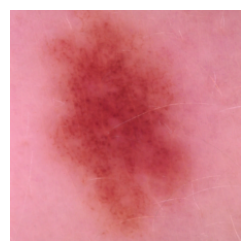

In [ ]:
model.eval()

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image, label = train_dataset[0]
input_tensor = image.unsqueeze(0).to(device)


with torch.no_grad() :
  output = model(input_tensor)
  pred = torch.argmax(output, dim=1).item()

img = image.permute(2, 1, 0).numpy()

plt.figure(figsize=(3,3))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
row = train_dataset.df.iloc[0]
print(row)

lesion_id        HAM_0004772
image_id        ISIC_0027223
dx                        nv
dx_type            follow_up
age                     35.0
sex                   female
localization            back
Name: 0, dtype: object


In [ ]:
print("CSV의 dx:", row["dx"])
print("숫자 label:", label)
print("label이 다시 문자로 바뀐 값:", idx2label[label])

CSV의 dx: nv
숫자 label: 5
label이 다시 문자로 바뀐 값: nv


In [ ]:
# max_train_batches = 32


# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# epochs = 50

# for epoch in range(epochs) :
#   model.train()
#   running_loss = 0.0
#   train_steps = 0

#   for batch_idx, (data, target) in enumerate(train_loader) :
#     if batch_idx >= max_train_batches :
#       break

#     data =data.to(device)
#     target = target.to(device)

#     optimizer.zero_grad()
#     output = model(data)
#     loss =criterion(output, target)

#     loss.backward()
#     optimizer.step()

#     running_loss += loss.item()
#     train_steps +=1

#   avg_loss = running_loss /train_steps
#   print(f"Epoch {epoch+1}/{epochs}, Loss : {avg_loss:.4f}")


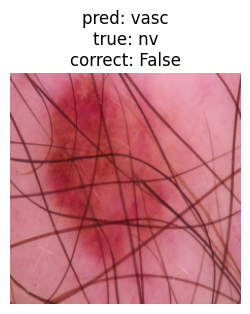

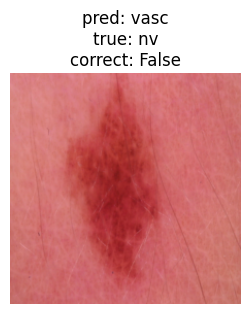

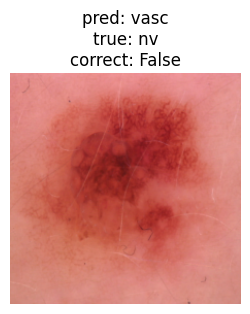

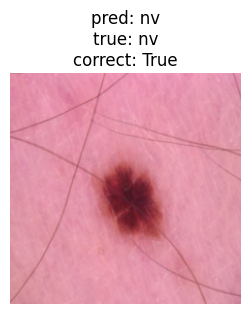

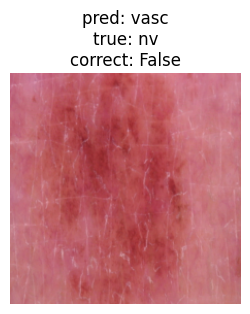

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, labels = next(iter(test_loader))   # test_loader에서 한 배치 가져오기
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

for i in range(5):   # 5장만 보기
    img = images_cpu[i].permute(1, 2, 0).numpy()

    pred_label = idx2label[preds_cpu[i].item()]
    true_label = idx2label[labels_cpu[i].item()]
    correct = pred_label == true_label

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"pred: {pred_label}\ntrue: {true_label}\ncorrect: {correct}")
    plt.axis("off")
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import wandb

# ---------------------------
# W&B 시작
# ---------------------------
wandb.init(
    project="ham10000-resnet18",
    name="weighted-ce-exp1",
    config={
        "epochs": 50,
        "max_train_batches": 30,
        "optimizer": "Adam",
        "lr": 0.001,
        "loss": "CrossEntropyLoss_weighted",
        "class_weights": [4, 4, 4, 4, 3, 1, 4],
        "model": "ResNet18"
    }
)
max_train_batches = 30

class_for_akiec = 6
class_for_bcc = 6
class_for_bkl = 6
class_for_df =6
class_for_mel = 4
class_for_nv = 1
class_for_vasc =6

class_weights = torch.tensor([4, 4, 4, 4, 3, 1, 4], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 25

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    train_steps = 0

    for batch_idx, (data, target) in enumerate(train_loader):
    #    if batch_idx >= max_train_batches:
     #       break
# 여기가 의미가 무엇이냐면, 위에서 배치사이즈가 32인데, 여기서 50개로 제한을 한다는 것은
# 한 번 학습시킬때, 이렇게 된 데이터셋을 50번만 꺼내쓴다 이런 의미가 된다
         data = data.to(device)
         target = target.to(device)

         optimizer.zero_grad()
         output = model(data)
         loss = criterion(output, target)

         loss.backward()
         optimizer.step()

         running_loss += loss.item()
         train_steps += 1

         _, preds = torch.max(output, 1)
         correct += (preds == target).sum().item()
         total += target.size(0)

    avg_loss = running_loss / train_steps
    acc = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")

# Loss 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

# Accuracy 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.show()


# ---------------------------
# 그래프도 W&B에 업로드
# ---------------------------
wandb.log({
    "train_loss_curve": wandb.plot.line_series(
        xs=list(range(1, epochs + 1)),
        ys=[train_losses],
        keys=["train_loss"],
        title="Training Loss Curve",
        xname="Epoch"
    ),
    "train_accuracy_curve": wandb.plot.line_series(
        xs=list(range(1, epochs + 1)),
        ys=[train_accuracies],
        keys=["train_accuracy"],
        title="Training Accuracy Curve",
        xname="Epoch"
    )
})

wandb.finish()

KeyboardInterrupt: 

In [ ]:
import pandas as pd

bcn_df = pd.read_csv("bcn20000_metadata_2026-04-16.csv")
bcn_df.head()

In [ ]:
label2idx

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, labels = next(iter(test_loader))   # test_loader에서 한 배치 가져오기
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

for i in range(5):   # 5장만 보기
    img = images_cpu[i].permute(1, 2, 0).numpy()

    pred_label = idx2label[preds_cpu[i].item()]
    true_label = idx2label[labels_cpu[i].item()]
    correct = pred_label == true_label

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"pred: {pred_label}\ntrue: {true_label}\ncorrect: {correct}")
    plt.axis("off")
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in val_loader:   # test_loader 써도 됨
        data = data.to(device)
        target = target.to(device)

        output = model(data)
        _, preds = torch.max(output, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()